In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

np.random.seed(42)

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
n = 1000

df = pd.DataFrame({
    "shipment_id": [f"SHP{i:05d}" for i in range(1, n + 1)],
    "shipment_date": pd.date_range("2025-01-01", periods=n, freq="D"),
    "transport_mode": np.random.choice(
        ["Road", "Rail", "Air", "Sea"],
        n,
        p=[0.50, 0.20, 0.15, 0.15]
    ),
    "region": np.random.choice(
        ["North", "South", "East", "West", "Central"],
        n
    )
})

df["distance_km"] = np.clip(
    np.random.gamma(3, 250, n),
    50,
    2000
)

df["shipment_volume"] = np.clip(
    np.random.gamma(4, 20, n),
    5,
    250
)

cost_per_km = df["transport_mode"].map({
    "Road": 1.8,
    "Rail": 1.2,
    "Air": 4.5,
    "Sea": 0.9
})

df["transportation_cost"] = np.maximum(
    100,
    df["distance_km"] * cost_per_km
    + df["shipment_volume"] * 8
    + np.random.normal(0, 150, n)
)

df["fuel_cost"] = np.maximum(
    20,
    df["distance_km"] * np.random.uniform(0.18, 0.35, n)
)

base_time = df["transport_mode"].map({
    "Road": 2.5,
    "Rail": 4.5,
    "Air": 1.2,
    "Sea": 7.0
})

df["delivery_time_days"] = np.maximum(
    0.5,
    base_time
    + df["distance_km"] / 350
    + df["shipment_volume"] / 180
    + np.random.normal(0, 1.5, n)
)

df["delay_days"] = np.maximum(
    -2,
    np.random.normal(0.5, 2.5, n)
)

df["delivery_status"] = np.where(
    df["delay_days"] > 0,
    "Delayed",
    "On-Time"
)

print("Dataset created successfully!")
print("Dataset shape:", df.shape)

df.head()

Dataset created successfully!
Dataset shape: (1000, 11)


,shipment_id,shipment_date,transport_mode,region,distance_km,shipment_volume,transportation_cost,fuel_cost,delivery_time_days,delay_days,delivery_status
0,SHP00001,2025-01-01,Road,West,85.160804,106.745102,1085.432453,20.356745,4.922197,0.676215,Delayed
1,SHP00002,2025-01-02,Sea,East,627.724614,88.435639,1450.434388,185.667457,9.932363,1.627662,Delayed
2,SHP00003,2025-01-03,Air,Central,617.396012,49.822307,3069.512455,150.267402,2.378148,1.676976,Delayed
3,SHP00004,2025-01-04,Rail,North,1149.857024,88.312788,2087.188144,235.429174,9.949200,-0.409049,On-Time
4,SHP00005,2025-01-05,Road,Central,654.447502,35.485549,1492.650156,162.982753,3.873706,-0.856248,On-Time


In [ ]:
print("Dataset Information:")
print(df.info())

print("\nDataset Shape:")
print(df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   shipment_id          1000 non-null   object        
 1   shipment_date        1000 non-null   datetime64[ns]
 2   transport_mode       1000 non-null   object        
 3   region               1000 non-null   object        
 4   distance_km          1000 non-null   float64       
 5   shipment_volume      1000 non-null   float64       
 6   transportation_cost  1000 non-null   float64       
 7   fuel_cost            1000 non-null   float64       
 8   delivery_time_days   1000 non-null   float64       
 9   delay_days           1000 non-null   float64       
 10  delivery_status      1000 non-null   object        
dtypes: datetime64[ns](1), float64(6), object(4)
memory usage: 86.1+ KB
None

Dataset Shape:
(1000, 11)

Missing Values:
shipment_id

In [ ]:
print("Descriptive Statistics:")
numeric_data = df.select_dtypes(include=np.number)
display(numeric_data.describe().round(2))

Descriptive Statistics:


,distance_km,shipment_volume,transportation_cost,fuel_cost,delivery_time_days,delay_days
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00
mean,757.77,78.88,2058.76,201.16,6.07,0.63
std,428.25,38.69,1211.39,122.79,2.66,2.16
min,50.00,7.59,111.81,20.00,0.50,-2.00
25%,434.48,51.59,1244.84,110.88,4.07,-1.27
50%,678.11,72.72,1744.72,176.52,6.02,0.39
75%,992.41,101.01,2498.92,257.30,7.81,2.05
max,2000.00,248.53,9427.68,695.48,16.27,8.19


In [ ]:
print("Average Delivery Time:", round(df["delivery_time_days"].mean(), 2), "days")
print("Average Shipment Volume:", round(df["shipment_volume"].mean(), 2))
print("Average Transportation Cost:", round(df["transportation_cost"].mean(), 2))
print("Average Distance:", round(df["distance_km"].mean(), 2), "km")
print("Average Fuel Cost:", round(df["fuel_cost"].mean(), 2))

Average Delivery Time: 6.07 days
Average Shipment Volume: 78.88
Average Transportation Cost: 2058.76
Average Distance: 757.77 km
Average Fuel Cost: 201.16


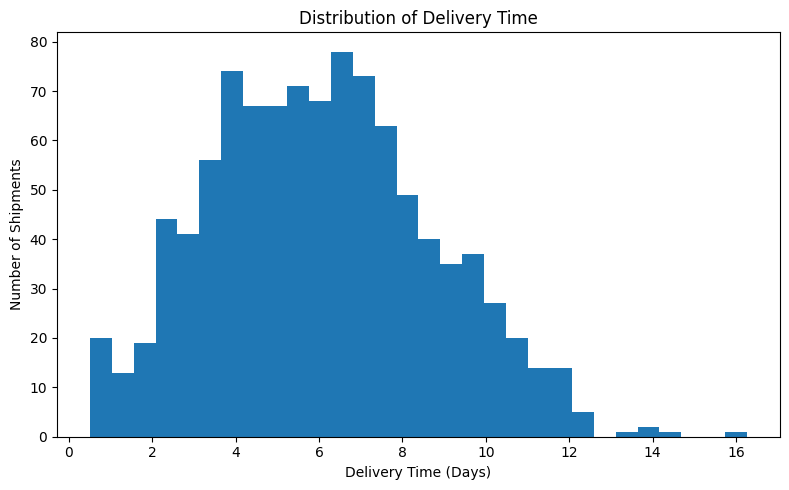

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(df["delivery_time_days"], bins=30)
plt.title("Distribution of Delivery Time")
plt.xlabel("Delivery Time (Days)")
plt.ylabel("Number of Shipments")
plt.tight_layout()
plt.show()

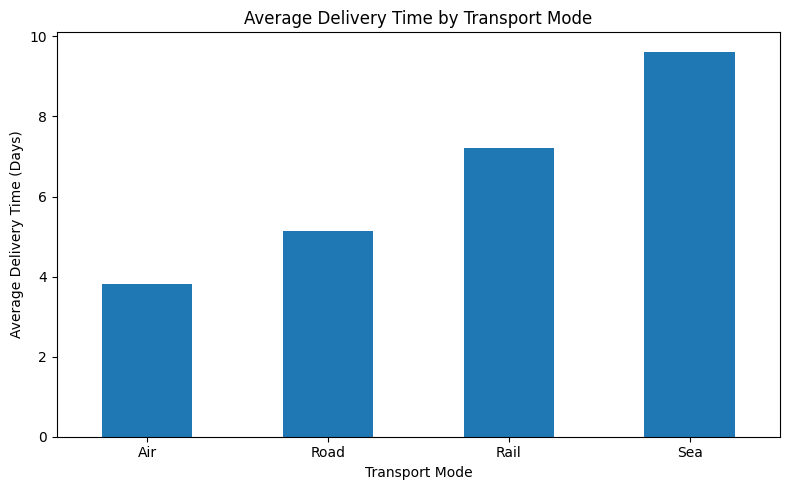

transport_mode
Air     3.82
Road    5.13
Rail    7.21
Sea     9.62
Name: delivery_time_days, dtype: float64


In [ ]:
mode_avg = df.groupby("transport_mode")["delivery_time_days"].mean().sort_values()

plt.figure(figsize=(8, 5))
mode_avg.plot(kind="bar")
plt.title("Average Delivery Time by Transport Mode")
plt.xlabel("Transport Mode")
plt.ylabel("Average Delivery Time (Days)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(mode_avg.round(2))

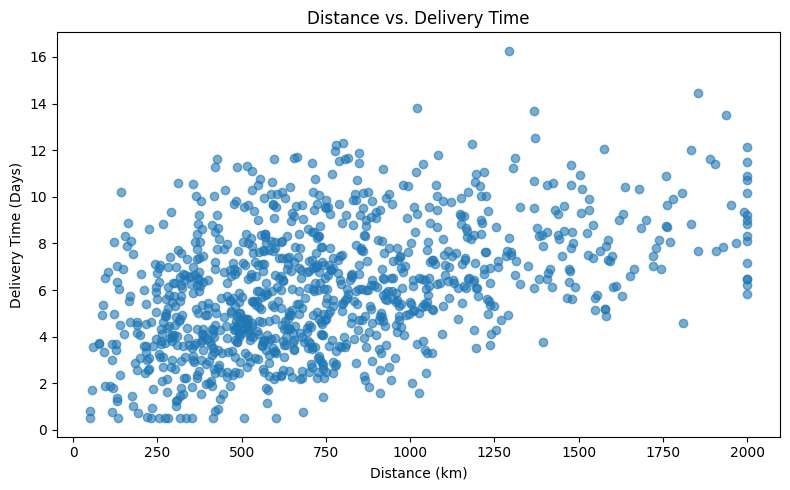

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["distance_km"],
    df["delivery_time_days"],
    alpha=0.6
)

plt.title("Distance vs. Delivery Time")
plt.xlabel("Distance (km)")
plt.ylabel("Delivery Time (Days)")
plt.tight_layout()
plt.show()

In [ ]:
target = "delivery_time_days"

features = [
    "shipment_volume",
    "transportation_cost",
    "distance_km",
    "fuel_cost",
    "transport_mode",
    "region"
]

X = df[features]
y = df[target]

categorical_features = ["transport_mode", "region"]
numeric_features = [
    "shipment_volume",
    "transportation_cost",
    "distance_km",
    "fuel_cost"
]

print("Target variable:", target)
print("Features:", features)

Target variable: delivery_time_days
Features: ['shipment_volume', 'transportation_cost', 'distance_km', 'fuel_cost', 'transport_mode', 'region']


In [ ]:
preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ("num", "passthrough", numeric_features)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print("Training records:", len(X_train))
print("Testing records:", len(X_test))

Training records: 800
Testing records: 200


In [ ]:
linear_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

linear_model.fit(X_train, y_train)

linear_pred = linear_model.predict(X_test)

linear_mae = mean_absolute_error(y_test, linear_pred)
linear_rmse = np.sqrt(mean_squared_error(y_test, linear_pred))
linear_r2 = r2_score(y_test, linear_pred)

print("Linear Regression Results")
print("-------------------------")
print("MAE :", round(linear_mae, 4))
print("RMSE:", round(linear_rmse, 4))
print("R²  :", round(linear_r2, 4))

Linear Regression Results
-------------------------
MAE : 1.1874
RMSE: 1.4269
R²  : 0.6991


In [ ]:
rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=200,
        max_depth=12,
        min_samples_split=4,
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Results")
print("---------------------")
print("MAE :", round(rf_mae, 4))
print("RMSE:", round(rf_rmse, 4))
print("R²  :", round(rf_r2, 4))

Random Forest Results
---------------------
MAE : 1.2495
RMSE: 1.5245
R²  : 0.6566


In [ ]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [linear_mae, rf_mae],
    "RMSE": [linear_rmse, rf_rmse],
    "R2": [linear_r2, rf_r2]
})

display(results.round(4))

,Model,MAE,RMSE,R2
0,Linear Regression,1.1874,1.4269,0.6991
1,Random Forest,1.2495,1.5245,0.6566


In [ ]:
cv_scores = cross_val_score(
    linear_model,
    X,
    y,
    cv=5,
    scoring="neg_root_mean_squared_error"
)

cv_rmse = -cv_scores

print("Linear Regression 5-Fold Cross-Validation")

for i, score in enumerate(cv_rmse, start=1):
    print(f"Fold {i} RMSE: {score:.4f}")

print("\nMean CV RMSE:", round(cv_rmse.mean(), 4))

Linear Regression 5-Fold Cross-Validation
Fold 1 RMSE: 1.5386
Fold 2 RMSE: 1.5470
Fold 3 RMSE: 1.6018
Fold 4 RMSE: 1.4680
Fold 5 RMSE: 1.5200

Mean CV RMSE: 1.5351


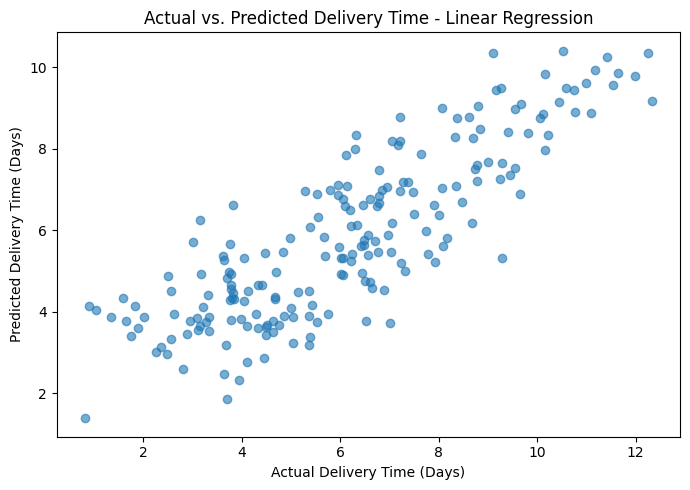

In [ ]:
plt.figure(figsize=(7, 5))

plt.scatter(
    y_test,
    linear_pred,
    alpha=0.6
)

plt.xlabel("Actual Delivery Time (Days)")
plt.ylabel("Predicted Delivery Time (Days)")
plt.title("Actual vs. Predicted Delivery Time - Linear Regression")

plt.tight_layout()
plt.show()

In [ ]:
mode_summary = df.groupby("transport_mode").agg(
    Average_Delivery_Time=("delivery_time_days", "mean"),
    Average_Transportation_Cost=("transportation_cost", "mean"),
    Average_Fuel_Cost=("fuel_cost", "mean")
).sort_values("Average_Delivery_Time")

print("Transport Mode Optimization Analysis")
print("------------------------------------")
display(mode_summary.round(2))

Transport Mode Optimization Analysis
------------------------------------


,Average_Delivery_Time,Average_Transportation_Cost,Average_Fuel_Cost
transport_mode,,,
Air,3.82,3867.67,187.90
Road,5.13,2003.34,202.37
Rail,7.21,1586.45,208.59
Sea,9.62,1290.06,198.75


In [ ]:
correlation = df[
    [
        "delivery_time_days",
        "shipment_volume",
        "transportation_cost",
        "distance_km",
        "fuel_cost",
        "delay_days"
    ]
].corr()["delivery_time_days"].sort_values(ascending=False)

print("Correlation with Delivery Time")
print("------------------------------")
print(correlation.round(3))

Correlation with Delivery Time
------------------------------
delivery_time_days     1.000
distance_km            0.448
fuel_cost              0.428
shipment_volume        0.086
delay_days             0.020
transportation_cost   -0.019
Name: delivery_time_days, dtype: float64


In [ ]:
df.to_csv("Week_4_Logistics_Synthetic_Dataset.csv", index=False)

results.to_csv(
    "Week_4_Model_Comparison.csv",
    index=False
)

mode_summary.to_csv(
    "Week_4_Transport_Mode_Summary.csv"
)

print("Files saved successfully!")
print("1. Week_4_Logistics_Synthetic_Dataset.csv")
print("2. Week_4_Model_Comparison.csv")
print("3. Week_4_Transport_Mode_Summary.csv")

Files saved successfully!
1. Week_4_Logistics_Synthetic_Dataset.csv
2. Week_4_Model_Comparison.csv
3. Week_4_Transport_Mode_Summary.csv
